Ciclo Crisis 52-55 ignorado (fuera de rango)
Ciclo Expansión 56-69 ignorado (fuera de rango)
Ciclo Recesión 70-81 ignorado (fuera de rango)


Ciclo Crisis 82-84 ignorado (fuera de rango)


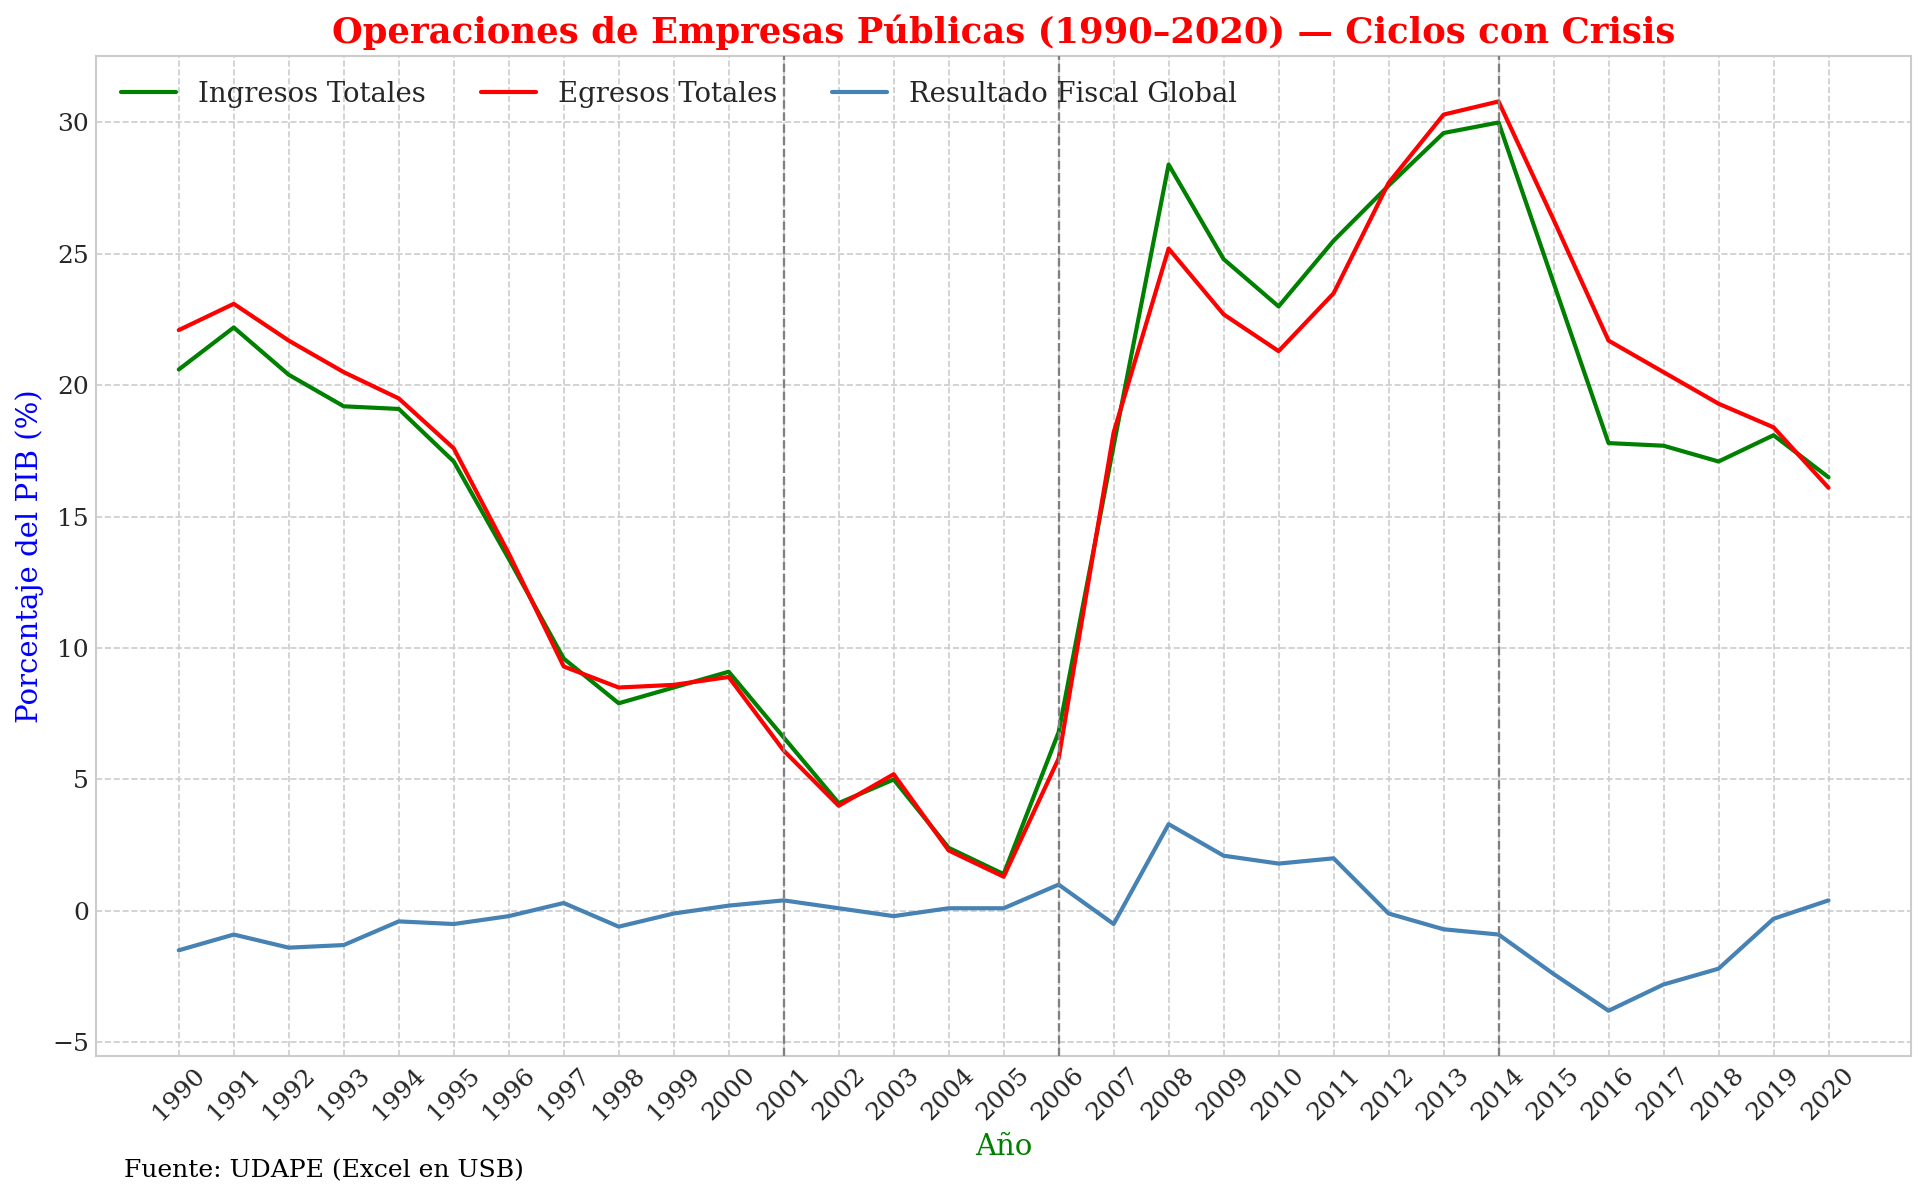

Gráfico guardado en: /home/navi/Desktop/archivos/DS/eco/Proyecto_macro/assets/tesis/serie_completa/operaciones_empresas_publicas/operaciones_empresas_publicas_ciclos.png


In [7]:
# ═══════════════════════════════════════════════════════════════════
# PRIMERA GRÁFICA: CICLOS CON CRISIS - LÍNEAS
# ═══════════════════════════════════════════════════════════════════

# ───────────────────────────── IMPORTS ──────────────────────────────
import os
import sys
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# IMPORTANTE: Importación correcta de las funciones auxiliares
from func_auxiliares.graficos_utils import (
    set_style,                          # Estilo corporativo
    init_base_plot,                     # Configuración base del gráfico
    add_hitos,                          # Líneas verticales de hitos
    add_cycle_means_multi,              # Medias por ciclo
    add_year_value_annotations,         # Anotaciones de valores por año
    add_period_growth_annotations_multi,# Tasas de crecimiento por período
    adjust_annot_years,                 # Ajustar años de anotación al DataFrame
    adjust_cycles,                      # Ajustar ciclos al DataFrame
    adjust_periods,                     # Ajustar períodos al DataFrame
    get_df                              # Función helper para cargar datos
)

from func_auxiliares.config import (
    DB_PATH,                            # Ruta a la base de datos
    CYCLES,                             # Diccionario de ciclos económicos
    ASSETS_DIR,                         # Directorio de assets
    annot_years,                        # Lista de años para anotaciones
    periodos_tasas,                     # Períodos para calcular tasas
    hitos_v,                            # Diccionario de hitos verticales
)

# ─────────────────────── 1. CONFIGURACIÓN GENERAL ───────────────────
output_dir = ASSETS_DIR / "serie_completa" / "operaciones_empresas_publicas"
os.makedirs(output_dir, exist_ok=True)
set_style()  # Aplica el estilo corporativo unificado

# ───────────────────────── 2. CARGA DE DATOS ────────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = (
        pd.read_sql(
            "SELECT * FROM operaciones_empresas_publicas",
            conn,
            index_col="año"
        )
        .sort_index()
    )

# ──────────────── 3. COMPONENTES Y PREPARACIÓN ──────────────────────
# Definir las series a graficar (tuplas de columna_df, etiqueta_display)
componentes = [
    ("ingresos_totales", "Ingresos Totales"),
    ("egresos_totales", "Egresos Totales"),
    ("resultado_fiscal_global", "Resultado Fiscal Global"),
]

# Extraer solo los nombres de columnas
cols_componentes = [col for col, _ in componentes]

# Definir colores para cada serie
colors = {
    "ingresos_totales": "green",
    "egresos_totales": "red", 
    "resultado_fiscal_global": "steelblue",
}

# Abreviaciones para anotaciones (texto más corto)
abbr_map = {
    "ingresos_totales": "IT",
    "egresos_totales": "ET",
    "resultado_fiscal_global": "RFG",
}

# ──────────────── 4. PREPARACIÓN DE CICLOS Y PERÍODOS ────────────────
# Ajustar configuraciones globales al DataFrame actual
annotate_years = adjust_annot_years(df, annot_years)
cycles = adjust_cycles(df, CYCLES)
periods = adjust_periods(df, periodos_tasas)

# Calcular estadísticas por ciclo (medias)
cycle_stats = {
    name: df.loc[period, cols_componentes].mean().to_dict()
    for name, period in cycles.items()
}

# ───────────── 5. OFFSETS Y UTILIDADES (POSICIONAMIENTO) ────────────

# A) Offsets para anotaciones de valores por año y serie
annotation_offsets = {
    # "ingresos_totales": {
    #     1990: (0, 0.5),     # (desplazamiento_x, desplazamiento_y)
    #     1995: (0, 0.5),
    #     2000: (0, 0.5),
    #     2006: (-1.5, 0.3),
    #     2014: (-2.5, -0.5),
    #     2020: (-0.8, -0.8),
    # },
    # "egresos_totales": {
    #     1990: (0, 0.3),
    #     1995: (0, 0.3),
    #     2000: (0, 0.3),
    #     2006: (1.2, -0.4),
    #     2014: (2.5, 0.3),
    #     2020: (0.8, -0.6),
    # },
    # "resultado_fiscal_global": {
    #     1990: (0, -0.5),
    #     1995: (0, -0.5),
    #     2000: (0, 0.5),
    #     2006: (0, -0.8),
    #     2014: (0, 0.5),
    #     2020: (0, 0.5),
    # },
}

# B) Offsets para líneas verticales de hitos
hitos_offset = {year: 0.8 for year in hitos_v}  # Altura relativa uniforme

# C) Offsets para medias por ciclo
medias_offsets = {
    # "Crisis 52-55": (1992, 0.85),        # (año_centro, altura_relativa)
    # "Expansión 56-69": (1992, 0.85),
    # "Recesión 70-81": (1992, 0.85),
    # "Crisis 82-85": (1992, 0.85),
    # "Expansión 85-00": (1992, 0.85),
    # "Crisis 01-05": (2002, 0.85),
    # "Expansión 06-14": (2009, 0.85),
    # "Recesión 15-24": (2017, 0.85),
}

# D) Offsets para tasas de crecimiento por período
tasas_offsets = {
    # "1990-1995": (1992, 0.75),
    # "1995-2000": (1997, 0.75),
    # "2000-2006": (2003, 0.75),
    # "2006-2014": (2010, 0.75),
    # "2014-2020": (2017, 0.75),
}

# ────────────────────────── 6. GRÁFICO BASE ──────────────────────────
fig, ax = init_base_plot(
    df=df,
    series=componentes,           # Lista de tuplas (columna, etiqueta)
    colors=colors,                # Diccionario de colores
    title=f"Operaciones de Empresas Públicas ({df.index.min()}–{df.index.max()}) — Ciclos con Crisis",
    xlabel="Año",
    ylabel="Porcentaje del PIB (%)",
    source_text="Fuente: UDAPE (Excel en USB)"
)

# ────────────────────── 7. ELEMENTOS GRÁFICOS ADICIONALES ────────────

# A) Líneas verticales de hitos históricos
add_hitos(ax, df.index, hitos_v, hitos_offset)

# B) Anotaciones de valores en años específicos
add_year_value_annotations(
    ax, df, annotate_years,
    cols_componentes, annotation_offsets, colors,
    arrow_lw=0.4,                # Grosor de flecha
)

# C) Medias por ciclo económico
add_cycle_means_multi(
    ax,
    cycle_stats,
    medias_offsets,
    abbr_map,
    colors,
    line_spacing=0.3             # Espaciado entre líneas
)

# D) Tasas de crecimiento por período
add_period_growth_annotations_multi(
    ax, df, periods,
    cols_componentes,
    tasas_offsets,
    colors,
    abbr_map,
)

# ────────────────────────── 8. FINALIZACIÓN ──────────────────────────
plt.tight_layout()

# Guardar en formato PNG de alta resolución
filename_base = f"{output_dir}/operaciones_empresas_publicas_ciclos"
fig.savefig(f"{filename_base}.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()  # IMPORTANTE: Cerrar la figura para liberar memoria

print(f"Gráfico guardado en: {filename_base}.png")

Ciclo Intervensionismo-estatal 52-84 ignorado (fuera de rango)


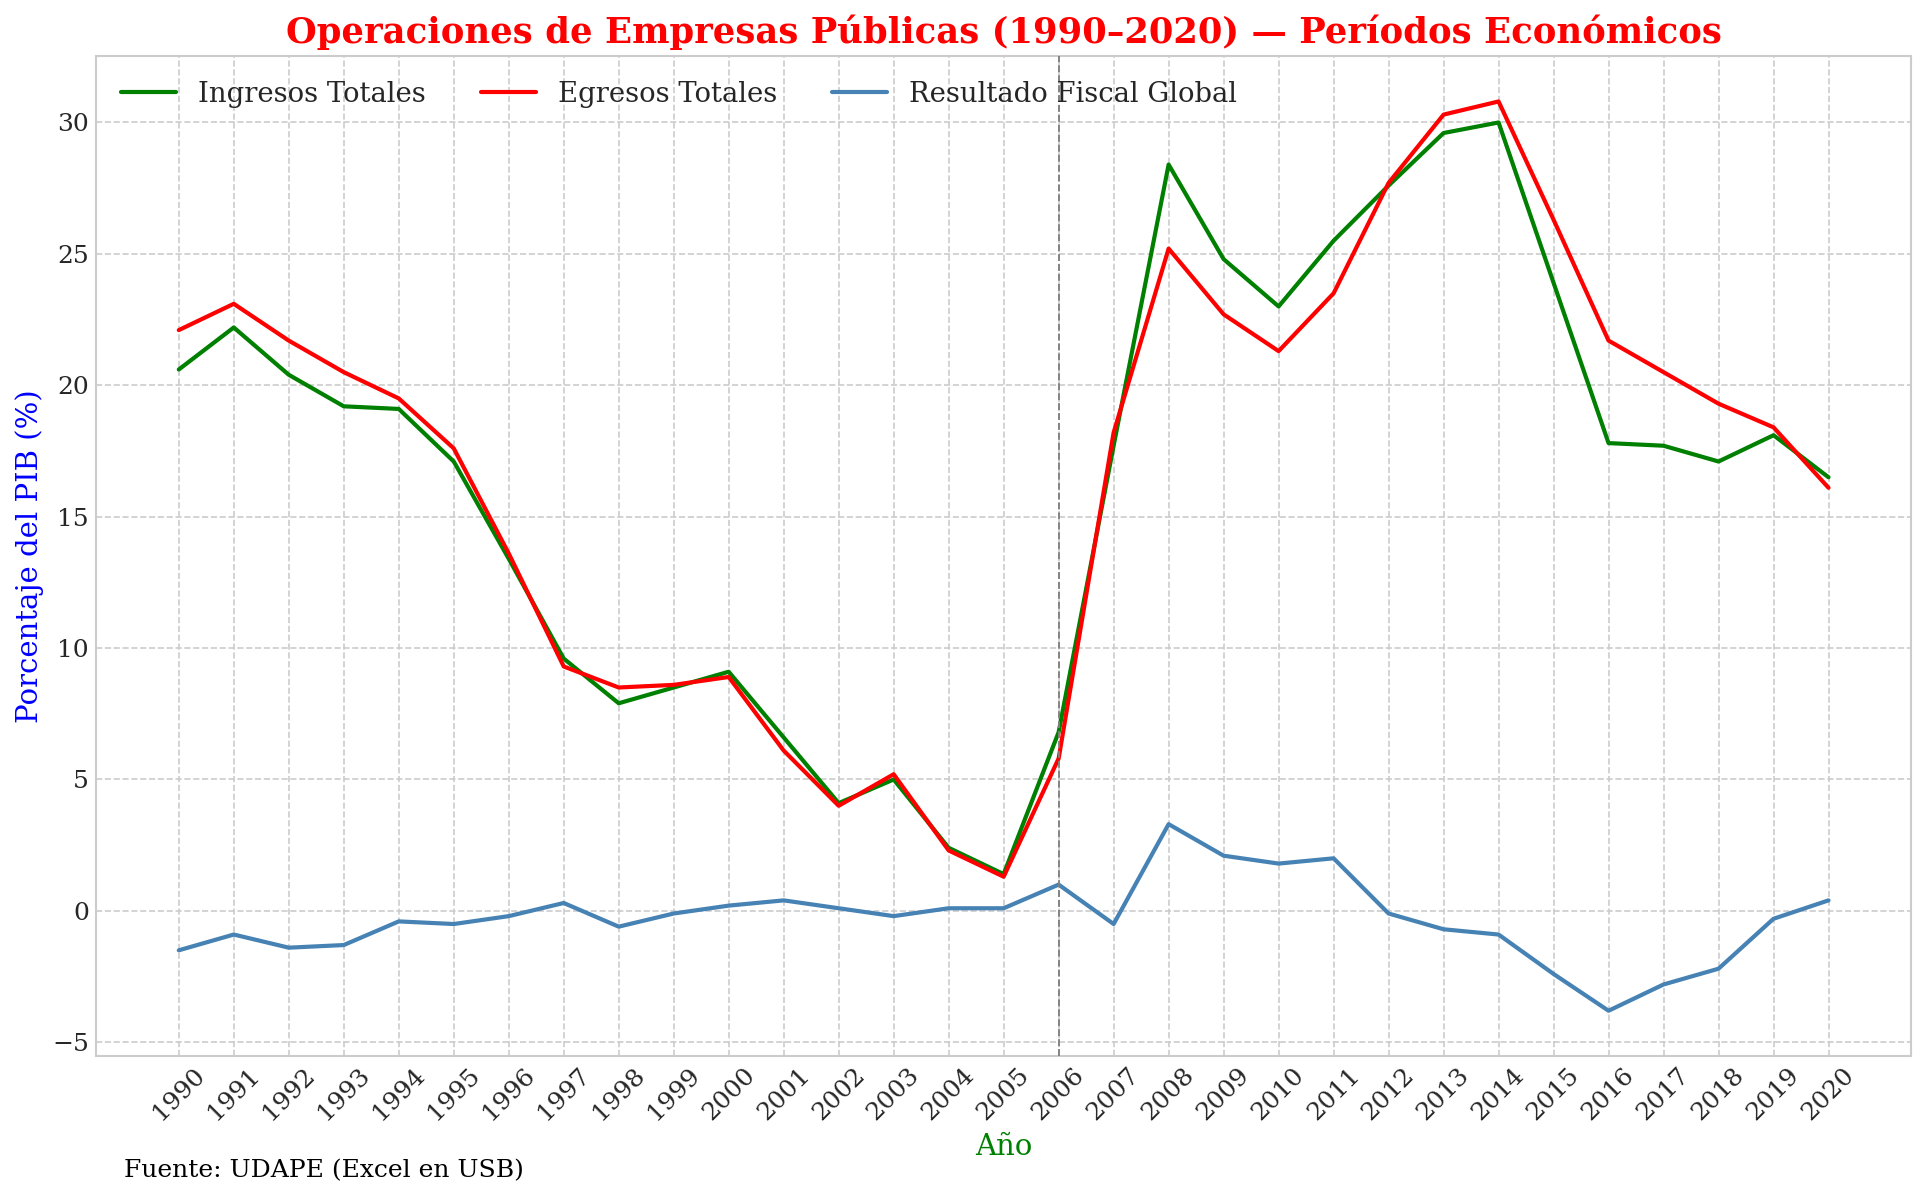

Gráfico de períodos guardado en: /home/navi/Desktop/archivos/DS/eco/Proyecto_macro/assets/tesis/serie_completa/operaciones_empresas_publicas/operaciones_empresas_publicas_periodos.png


In [8]:
# ═══════════════════════════════════════════════════════════════════
# SEGUNDA GRÁFICA: PERÍODOS ESTRUCTURALES - LÍNEAS
# ═══════════════════════════════════════════════════════════════════

from func_auxiliares.config import (
    CYCLES_PERIODOS,                    # Ciclos por períodos estructurales
    annot_years_periodos,               # Años para anotaciones en períodos
    periodos_tasas_periodos,            # Períodos estructurales para tasas
    hitos_v_periodos                    # Hitos verticales para períodos
)

# Ajustar configuraciones específicas para períodos estructurales
annotate_years_periodos = adjust_annot_years(df, annot_years_periodos)
cycles_stats_periodos = {
    name: df.loc[period, cols_componentes].mean().to_dict()
    for name, period in adjust_cycles(df, CYCLES_PERIODOS).items()
}
periodos_periodos = adjust_periods(df, periodos_tasas_periodos)

# Offsets específicos para períodos estructurales
annotation_offsets_periodos = {
    # "ingresos_totales": {
    #     1990: (0, 0.5),      # Neoliberalismo inicial
    #     2006: (-2, 0.3),     # Inicio neodesarrollismo
    #     2014: (3.5, -0.4),   # Punto medio neodesarrollismo
    #     2020: (0, -0.8),     # Final de serie
    # },
    # "egresos_totales": {
    #     1990: (0, 0.3),
    #     2006: (1.2, -0.4),
    #     2014: (2.5, 0.3),
    #     2020: (0.8, -0.6),
    # },
    # "resultado_fiscal_global": {
    #     1990: (0, -0.5),
    #     2006: (0, -0.8),
    #     2014: (0, 0.5),
    #     2020: (0, 0.5),
    # },
}

# Hitos verticales para períodos estructurales
hitos_offset_periodos = {year: 0.8 for year in hitos_v_periodos}

# Medias por período estructural
medias_offsets_periodos = {
    # 'Neoliberalismo 85-05': (1992, 0.85),          # Posición en neoliberalismo
    # 'Neodesarrollismo 06-24': (2010, 0.85),        # Posición en neodesarrollismo
}

# Tasas de crecimiento por período estructural
tasas_offsets_periodos = {
    # '1990-2005': (1997, 0.75),       # Neoliberalismo
    # '2006-2020': (2013, 0.75),       # Neodesarrollismo
}

# Construcción del gráfico de períodos estructurales
fig, ax = init_base_plot(
    df, componentes, colors,
    f"Operaciones de Empresas Públicas ({df.index.min()}–{df.index.max()}) — Períodos Económicos",
    "Año", "Porcentaje del PIB (%)",
    source_text="Fuente: UDAPE (Excel en USB)"
)

# Elementos gráficos específicos para períodos
add_hitos(ax, df.index, hitos_v_periodos, hitos_offset_periodos, line_kwargs={'lw':0.9})

add_cycle_means_multi(
    ax, cycles_stats_periodos, medias_offsets_periodos,
    abbr_map, colors, line_spacing=0.3
)

add_year_value_annotations(
    ax, df, annotate_years_periodos, cols_componentes,
    annotation_offsets_periodos, colors, arrow_lw=0.5
)

add_period_growth_annotations_multi(
    ax, df, periodos_periodos, cols_componentes,
    tasas_offsets_periodos, colors, abbr_map
)

plt.tight_layout()
filename_periodos = f"{output_dir}/operaciones_empresas_publicas_periodos"
fig.savefig(f"{filename_periodos}.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Gráfico de períodos guardado en: {filename_periodos}.png")